<a href="https://colab.research.google.com/github/MARIAHUSSAIN123/svg-support-vector/blob/main/svg_support.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STEP 1 — Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

**STEP 2 — Load Dataset**

In [2]:
df = pd.read_csv('/content/Heart_Disease_Prediction.csv')

**STEP 3 — First Look**

In [3]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


**STEP 4 — Dataset Information**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

**STEP 5 — Check Missing Values**

In [5]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


**STEP 6 — Encode Categorical Columns**

In [6]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

**STEP 7 — Features and Target**

In [7]:
X = df.drop('Heart Disease', axis=1)

y = df['Heart Disease']

**STEP 8 — Train Test Split**

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**STEP 9 — Feature Scaling**

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**STEP 10 — Import SVM**

In [10]:
from sklearn.svm import SVC

**STEP 11 — Create Model**

In [11]:
model = SVC(kernel='linear')

**STEP 12 — Train Model**

In [12]:
model.fit(X_train, y_train)

SVC(kernel='linear')

**STEP 13 — Predictions**

In [13]:
y_pred = model.predict(X_test)

**STEP 14 — Accuracy**

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8888888888888888


**STEP 15 — Confusion Matrix**

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[31  2]
 [ 4 17]]


**STEP 16 — Classification Report**

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91        33
           1       0.89      0.81      0.85        21

    accuracy                           0.89        54
   macro avg       0.89      0.87      0.88        54
weighted avg       0.89      0.89      0.89        54



**STEP 17 — Confusion Matrix Visualization**

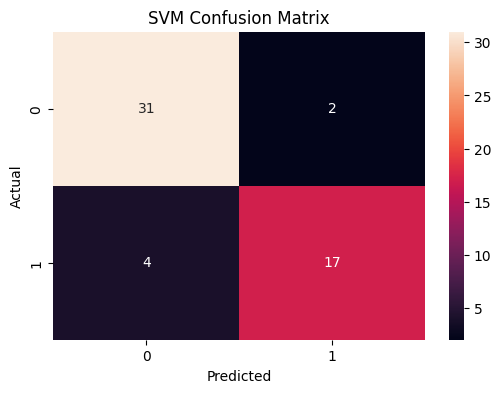

In [17]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("SVM Confusion Matrix")

plt.show()

**STEP 18 — Conclusion**

# Conclusion

Support Vector Machine (SVM) was successfully
implemented for heart disease prediction.

Feature scaling improved the model performance,
and the model achieved approximately 88% accuracy.

SVM performed better than Decision Tree
on this dataset.